<h1><font color="blue">행정 안정부 휴게 음식점</font></h1>

In [1]:
import pandas as pd

In [4]:
# '번호','개방서비스명','개방서비스아이디','개방자치단체코드','관리번호','','인허가취소일자','',
# '','상세영업상태코드','상세영업상태명','폐업일자','휴업시작일자','휴업종료일자','재개업일자','',
# '소재지면적','소재지우편번호','소재지전체주소',,'','최종수정시점','데이터갱신구분',
# '데이터갱신일자',,'위생업태명','남성종사자수','여성종사자수','영업장주변구분명',
# '등급구분명','급수시설구분명','총직원수','본사직원수','공장사무직직원수','공장판매직직원수','공장생산직직원수',
# '건물소유구분명','보증액','월세액','다중이용업소여부','시설총규모','전통업소지정번호','전통업소주된음식','홈페이지',

In [5]:
dataIn = './../data/'
column_list = ['사업장명', '인허가일자', '영업상태구분코드', '영업상태명', '소재지전화', '도로명전체주소','도로명우편번호', \
              '업태구분명','좌표정보(x)','좌표정보(y)']

'''
usecols 매개 변수는 읽어올 열(column)을 선택할 수 있습니다.
low_memory 매개변수를 False로 설정하여 메모리를 더 사용하여 데이터 유형을 추론하도록 할 수 있습니다.
'''

snackFood = pd.read_csv(dataIn + '행정안전부_휴게음식점.csv', usecols= column_list, encoding='CP949', low_memory=False)

addresslist = snackFood['도로명전체주소'].str.split()
snackFood['시도'] = addresslist.str.get(0)
snackFood['군구'] = addresslist.str.get(1)

snackFood.head() # 데이터가 많으므로 시간이 약간 걸림

,인허가일자,영업상태구분코드,영업상태명,소재지전화,도로명전체주소,도로명우편번호,사업장명,업태구분명,좌표정보(x),좌표정보(y),시도,군구
0,2023-09-22,3,폐업,NaN,"경기도 이천시 장호원읍 서동대로8759번길 117, 장호원농산물유통센터 17호",17421.0,주민자치,일반조리판매,254385.408140,402006.771068,경기도,이천시
1,2023-09-21,3,폐업,NaN,"경기도 남양주시 와부읍 수레로 22, 1층 일부호",12209.0,덕소낙원떡집,떡카페,218881.556118,453877.413941,경기도,남양주시
2,2023-09-22,3,폐업,NaN,NaN,NaN,오븐프레시,기타 휴게음식점,237432.906176,252513.683119,NaN,NaN
3,2023-09-22,3,폐업,NaN,"서울특별시 서초구 신반포로 176, 신세계백화점 강남점 지하1층 식품행사장 (반포동)",6546.0,리은푸드,일반조리판매,200250.447805,444683.220506,서울특별시,서초구
4,2023-09-22,3,폐업,NaN,"울산광역시 중구 샛강남길 5, 태화강 국가정원 대나무생태원 옆 잔디밭 (태화동)",44457.0,카페지와이(고고마켓),커피숍,NaN,NaN,울산광역시,중구


In [6]:
# usecols을 사용하더라도, 파일에 존재하는 컬럼의 순서대로 출력이 됩니다.
# 컬럼의 순서를 내 입맛대로 재배치하도록 합니다.
data_01 = ['사업장명', '시도', '군구', '소재지전화', '도로명전체주소', '업태구분명','좌표정보(x)','좌표정보(y)']
data_02 = ['인허가일자', '영업상태구분코드','도로명우편번호', '영업상태명']
myordering = data_01 + data_02
print('컬럼 재배치 현황 : \n' + str(myordering))

컬럼 재배치 현황 : 
['사업장명', '시도', '군구', '소재지전화', '도로명전체주소', '업태구분명', '좌표정보(x)', '좌표정보(y)', '인허가일자', '영업상태구분코드', '도로명우편번호', '영업상태명']


In [7]:
result = set(snackFood.columns) == set(myordering)
print('최초 컬럼 정보와 동일한가 ? ' +str(result))

최초 컬럼 정보와 동일한가 ? True


In [8]:
snackFood = snackFood[myordering]
snackFood.head()

,사업장명,시도,군구,소재지전화,도로명전체주소,업태구분명,좌표정보(x),좌표정보(y),인허가일자,영업상태구분코드,도로명우편번호,영업상태명
0,주민자치,경기도,이천시,NaN,"경기도 이천시 장호원읍 서동대로8759번길 117, 장호원농산물유통센터 17호",일반조리판매,254385.408140,402006.771068,2023-09-22,3,17421.0,폐업
1,덕소낙원떡집,경기도,남양주시,NaN,"경기도 남양주시 와부읍 수레로 22, 1층 일부호",떡카페,218881.556118,453877.413941,2023-09-21,3,12209.0,폐업
2,오븐프레시,NaN,NaN,NaN,NaN,기타 휴게음식점,237432.906176,252513.683119,2023-09-22,3,NaN,폐업
3,리은푸드,서울특별시,서초구,NaN,"서울특별시 서초구 신반포로 176, 신세계백화점 강남점 지하1층 식품행사장 (반포동)",일반조리판매,200250.447805,444683.220506,2023-09-22,3,6546.0,폐업
4,카페지와이(고고마켓),울산광역시,중구,NaN,"울산광역시 중구 샛강남길 5, 태화강 국가정원 대나무생태원 옆 잔디밭 (태화동)",커피숍,NaN,NaN,2023-09-22,3,44457.0,폐업


In [9]:
print('행 개수 : ' + str(snackFood.shape[0]))
print('열 개수 : ' + str(snackFood.shape[1]))

행 개수 : 546853
열 개수 : 12


In [10]:
snackFood['시도'].unique()

array(['경기도', nan, '서울특별시', '울산광역시', '충청북도', '경상남도', '전라북도', '세종특별자치시',
       '부산광역시', '인천광역시', '대전광역시', '전라남도', '경상북도', '대구광역시', '강원특별자치도',
       '충청남도', '광주광역시', '제주특별자치도'], dtype=object)

In [11]:
snackFood['업태구분명'].unique()

array(['일반조리판매', '떡카페', '기타 휴게음식점', '커피숍', '백화점', '편의점', '아이스크림', '다방',
       '푸드트럭', '패스트푸드', '전통찻집', '키즈카페', '유원지', '고속도로', '철도역구내', '극장',
       '과자점', '관광호텔', nan, '한식', '분식', '공항', '김밥(도시락)', '룸살롱', '기타',
       '식품소분업', '호프/통닭', '까페', '경양식', '식육(숯불구이)', '단란주점'], dtype=object)

In [12]:
query_sido = ['경기도', '서울특별시', '인천광역시']
buiness_type = ['커피숍', '다방', '전통찻집']
sql = "시도 in @query_sido and 업태구분명 in @buiness_type"
capital_region = snackFood.query(sql)
capital_region.head() # 수도권

,사업장명,시도,군구,소재지전화,도로명전체주소,업태구분명,좌표정보(x),좌표정보(y),인허가일자,영업상태구분코드,도로명우편번호,영업상태명
30,텐퍼센트커피(Tenpercent coffee),서울특별시,노원구,NaN,"서울특별시 노원구 동일로 1036, 1층 (공릉동)",커피숍,206495.517361,457808.623820,2023-09-18,3,1845.0,폐업
40,발도스커피 송도점,인천광역시,연수구,NaN,"인천광역시 연수구 하모니로177번길 49, 형지글로벌 패션복합센터 3동 106호 (...",커피숍,168438.212970,430754.796199,2023-09-15,3,22013.0,폐업
45,커피대학교,인천광역시,미추홀구,NaN,"인천광역시 미추홀구 매소홀로 618, 문학경기장 동문호 (문학동)",커피숍,172576.611810,437142.079771,2023-09-15,3,22234.0,폐업
58,오산청년마을협동조합(바이어스),경기도,오산시,NaN,"경기도 오산시 성호대로 141, 오산시청 1층 (오산동)",커피숍,206813.806659,405344.983891,2023-09-15,3,18132.0,폐업
111,달콩,경기도,시흥시,NaN,"경기도 시흥시 동서로 287, 갯골생태공원 (장곡동)",다방,180521.995338,432122.395128,2023-09-19,3,14971.0,폐업


In [13]:
# '시도'별 '업태구분명'별 개수 파악하기
capital_buiness_type = capital_region.groupby(['시도', '업태구분명'])['업태구분명']
capital_buiness_type = capital_buiness_type.count().sort_values(ascending=False)
capital_buiness_type = capital_buiness_type.head()
capital_buiness_type.to_frame()

,,업태구분명
시도,업태구분명,
경기도,커피숍,35948
서울특별시,커피숍,32142
인천광역시,커피숍,7917
경기도,다방,3089
서울특별시,다방,2490


In [14]:
# '커피숍'만 추출하기
bool = capital_buiness_type.index.get_level_values(1)=='커피숍'
capital_coffee = capital_buiness_type[bool] 
capital_coffee.index = capital_coffee.index.get_level_values(0)
capital_coffee.to_frame()

,업태구분명
시도,
경기도,35948
서울특별시,32142
인천광역시,7917


In [15]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

Text(0.5, 1.0, '수도권 커피숍 비율')

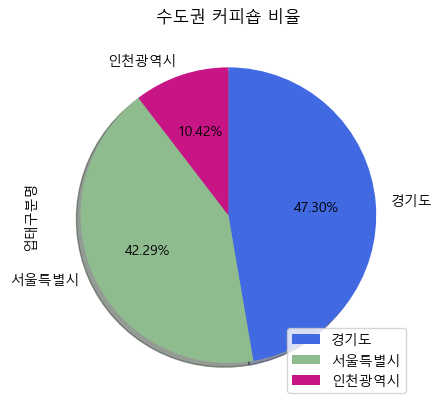

In [16]:
mycolors = ['RoyalBlue', 'DarkSeaGreen', 'MediumVioletRed']
mylabel = capital_coffee.index
capital_coffee.plot(kind='pie', labels=mylabel, shadow=True, explode=(0, 0, 0),
        colors=mycolors, autopct='%1.2f%%', startangle=90, counterclock=False)
plt.grid(True)
plt.legend(loc=4)
plt.title('수도권 커피숍 비율')

In [17]:
# 경기도가 가장 많습니다. 경기도의 시도에서 커피 숍이 가장 많은 곳을 찾아 보겠습니다.
gyeonggido = capital_region.loc[capital_region['시도']=='경기도']
print('\'경기도 군구\' 목록')
gyeonggido['군구'].unique() # 

'경기도 군구' 목록


array(['오산시', '시흥시', '하남시', '고양시', '용인시', '부천시', '김포시', '수원시', '화성시',
       '양평군', '파주시', '구리시', '양주시', '남양주시', '성남시', '안양시', '안산시', '광주시',
       '과천시', '가평군', '평택시', '여주시', '광명시', '포천시', '의정부시', '군포시', '이천시',
       '안성시', '연천군', '의왕시', '동두천시'], dtype=object)

In [18]:
gyeonggido.head()

,사업장명,시도,군구,소재지전화,도로명전체주소,업태구분명,좌표정보(x),좌표정보(y),인허가일자,영업상태구분코드,도로명우편번호,영업상태명
58,오산청년마을협동조합(바이어스),경기도,오산시,NaN,"경기도 오산시 성호대로 141, 오산시청 1층 (오산동)",커피숍,206813.806659,405344.983891,2023-09-15,3,18132.0,폐업
111,달콩,경기도,시흥시,NaN,"경기도 시흥시 동서로 287, 갯골생태공원 (장곡동)",다방,180521.995338,432122.395128,2023-09-19,3,14971.0,폐업
112,배곧마루카페,경기도,시흥시,NaN,"경기도 시흥시 동서로 287, 갯골생태공원 (장곡동)",다방,180521.995338,432122.395128,2023-09-19,3,14971.0,폐업
128,(주)아이알엔디벨로퍼지 G9방위대,경기도,하남시,NaN,"경기도 하남시 미사강변대로226번안길 21, 파인빌딩 1층 101-108호 (망월동)",커피숍,216337.226029,451901.212893,2022-05-17,3,12909.0,폐업
129,화해숲 스튜디오 북카페,경기도,하남시,NaN,"경기도 하남시 미사대로 410, 미사강변 오벨리스크 2층 244호 (망월동)",커피숍,217344.753524,451638.787397,2022-05-17,3,12912.0,폐업


In [19]:
gyeonggido_group = gyeonggido.groupby('군구')['군구']
gyeonggido_result = gyeonggido_group.count().sort_values(ascending=False)
gyeonggido_result = gyeonggido_result
gyeonggido_result.to_frame().head()

,군구
군구,
고양시,3863
수원시,3419
성남시,3205
용인시,2893
화성시,2577


In [20]:
# '고양시' 데이터가 가장 많습니다.
goyangsi = gyeonggido.loc[gyeonggido['군구']=='고양시']
print('\'고양시\' 목록')
goyangsi['도로명전체주소'].to_frame()

'고양시' 목록


,도로명전체주소
130,"경기도 고양시 덕양구 동송로 70, 힐스테이트 삼송역 지2층 B21호 (삼송동)"
159,"경기도 고양시 일산서구 킨텍스로 217-60, 킨텍스 제1전시장 2홀내 일부호 (..."
162,"경기도 고양시 일산서구 킨텍스로 217-60, 킨텍스 제1전시장 2홀내 일부호 (대화동)"
170,"경기도 고양시 덕양구 지도로92번길 9, 낙원빌딩 3층 일부호 (토당동)"
197,"경기도 고양시 일산동구 중앙로1275번길 38-31, 라페스타A 209호 (장항동)"
...,...
537408,"경기도 고양시 일산동구 숲속마을2로 120, 4층 일부호 (풍동)"
537425,"경기도 고양시 덕양구 호국로779번길 26, 수복빌딩 1(일부)층 (주교동)"
537466,"경기도 고양시 일산동구 백마로 195, 일산방송COMPLEX방송관련시설 1층 1-1..."
537566,"경기도 고양시 일산동구 무궁화로141번길 16-7, 1층 일부호 (정발산동)"


In [21]:
# 애니골에 있는 커피 숍 찾기

In [22]:
anigol = goyangsi[goyangsi['도로명전체주소'].str.contains('애니골')]
anigol

,사업장명,시도,군구,소재지전화,도로명전체주소,업태구분명,좌표정보(x),좌표정보(y),인허가일자,영업상태구분코드,도로명우편번호,영업상태명
98038,베르포레,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길43번길 42, 1,2층 전체호 (풍동)",커피숍,181364.327412,463443.070429,2020-07-03,3,10301.0,폐업
133252,바른ori(오리),경기도,고양시,031 9074941,"경기도 고양시 일산동구 애니골길 52, 나동 1층 일부호 (풍동)",커피숍,181635.665156,463343.831814,2007-03-06,3,10301.0,폐업
171554,SKETCH1993(스케치1993),경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 104, 1층 전체호 (풍동)",커피숍,181693.898602,463712.826061,2015-12-04,3,10311.0,폐업
171882,천년찻집,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 14-47, 가동 1,2층 (풍동)",커피숍,181505.427447,462905.102848,2015-02-05,3,NaN,폐업
172653,갤러리카페밀(Miiiiil),경기도,고양시,031 905 8756,"경기도 고양시 일산동구 애니골길 74 (풍동, 3층전체)",커피숍,181585.438273,463536.860233,2013-08-01,3,10301.0,폐업
173346,휴까페,경기도,고양시,031 908 4337,"경기도 고양시 일산동구 애니골길 26-20, 1층 일부호 (풍동, 이가빌딩 )",커피숍,181547.575639,463029.472402,2012-04-20,3,10301.0,폐업
236073,슬로카페(SLOW CAFE)달팽이,경기도,고양시,070 88810282,"경기도 고양시 일산동구 애니골길 116, A동 3층 전부호 (풍동)",커피숍,NaN,NaN,2014-06-23,3,10311.0,폐업
349432,카페401,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 97, 고양국제청소년문화센터 웰레스센터동 1층 일부...",커피숍,181563.394170,463799.877105,2021-02-01,1,10311.0,영업/정상
390858,백마화사랑,경기도,고양시,031 904 2611,"경기도 고양시 일산동구 애니골길 14-14, 1층 일부호 (풍동)",커피숍,181448.931303,462945.024586,2020-11-17,1,10301.0,영업/정상
430224,딱!좋아커피,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 6, 마두골프클럽 A동 2층 일부호 (풍동)",커피숍,181390.238079,462886.750244,2023-02-10,1,10301.0,영업/정상


In [23]:
unknown = ~anigol['좌표정보(x)'].isnull() # ~은 부호 반전
anigol = anigol[unknown]
anigol

,사업장명,시도,군구,소재지전화,도로명전체주소,업태구분명,좌표정보(x),좌표정보(y),인허가일자,영업상태구분코드,도로명우편번호,영업상태명
98038,베르포레,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길43번길 42, 1,2층 전체호 (풍동)",커피숍,181364.327412,463443.070429,2020-07-03,3,10301.0,폐업
133252,바른ori(오리),경기도,고양시,031 9074941,"경기도 고양시 일산동구 애니골길 52, 나동 1층 일부호 (풍동)",커피숍,181635.665156,463343.831814,2007-03-06,3,10301.0,폐업
171554,SKETCH1993(스케치1993),경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 104, 1층 전체호 (풍동)",커피숍,181693.898602,463712.826061,2015-12-04,3,10311.0,폐업
171882,천년찻집,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 14-47, 가동 1,2층 (풍동)",커피숍,181505.427447,462905.102848,2015-02-05,3,NaN,폐업
172653,갤러리카페밀(Miiiiil),경기도,고양시,031 905 8756,"경기도 고양시 일산동구 애니골길 74 (풍동, 3층전체)",커피숍,181585.438273,463536.860233,2013-08-01,3,10301.0,폐업
173346,휴까페,경기도,고양시,031 908 4337,"경기도 고양시 일산동구 애니골길 26-20, 1층 일부호 (풍동, 이가빌딩 )",커피숍,181547.575639,463029.472402,2012-04-20,3,10301.0,폐업
349432,카페401,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 97, 고양국제청소년문화센터 웰레스센터동 1층 일부...",커피숍,181563.394170,463799.877105,2021-02-01,1,10311.0,영업/정상
390858,백마화사랑,경기도,고양시,031 904 2611,"경기도 고양시 일산동구 애니골길 14-14, 1층 일부호 (풍동)",커피숍,181448.931303,462945.024586,2020-11-17,1,10301.0,영업/정상
430224,딱!좋아커피,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 6, 마두골프클럽 A동 2층 일부호 (풍동)",커피숍,181390.238079,462886.750244,2023-02-10,1,10301.0,영업/정상
437237,엘피조커피,경기도,고양시,NaN,"경기도 고양시 일산동구 애니골길 14-23, 1층 전체호 (풍동)",커피숍,181524.950384,462934.625941,2020-06-23,1,10301.0,영업/정상


In [24]:
# 고속도로에 위치한 음식점 음주행위가 허용되지 아니하는 업소로 간단한 조리음식과 음료를 즐길 수 있는 업소 데이터로 인허가일자, 
# 영업상태, 사업장명, 소재지주소 등의 정보 확인이 가능합니다.
# 좌표계 : 보정계수 안들어간 Bessel 중부원점TM(EPSG:2097)
# 지도는 위경도가 아니어서 그리지 못함.
# folium에서 Bessel 좌표계를 이용하여 그리는 방법?

In [30]:
import folium

mylocation = (37.674, 126.792)
mapObject = folium.Map(location=mylocation, zoom_start=15)

for idxname in anigol.index:
    onedata = anigol.loc[idxname]
#     print(onedata)
#     print()
    myposition = (onedata['좌표정보(x)'], onedata['좌표정보(y)'])
    print(myposition)
    marker = folium.Marker(myposition, popup=idxname, \
                    icon=folium.Icon(color='red', icon='info-sign')).add_to(mapObject)
# end for 

mapfilename = 'anigol_map.html' 
mapObject.save(mapfilename) # HTML 파일로 저장
print(mapfilename + ' 파일 저장 완료')

mapObject # Jupyter Notebook에서 바로 출력

(181364.327411601, 463443.070428937)
(181635.665156493, 463343.831813644)
(181693.898602239, 463712.826061448)
(181505.427446552, 462905.102847781)
(181585.438273254, 463536.860232598)
(181547.575639175, 463029.472402347)
(181563.394170421, 463799.877105059)
(181448.931302878, 462945.02458571)
(181390.238078739, 462886.750244295)
(181524.950384478, 462934.625940842)
(181441.923274262, 463007.538541924)
(181327.793263013, 463018.102734179)
anigol_map.html 파일 저장 완료


In [26]:
# 컬럼 재배치 현황 : 
# ['사업장명', '시도', '군구', '소재지전화', '도로명전체주소', '업태구분명', '좌표정보(x)', '좌표정보(y)', 
# '인허가일자', '영업상태구분코드', '도로명우편번호', '영업상태명']

In [27]:
# result에 대하여 '영업/정상'과 '폐업'에 대한 색상을 구분하여 지도를 그려 보세요.